In [1]:
import numpy as np
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

In [2]:
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()
print({"the training set data the shape " + str(X_train.shape)})
print({"the training set labels hast the shape " + str(Y_train.shape)})
print({"the testing set data the shape " + str(X_test.shape)})
print({"the testing set labels hast the shape " + str(Y_test.shape)})

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
{'the training set data the shape (60000, 28, 28)'}
{'the training set labels hast the shape (60000,)'}
{'the testing set data the shape (10000, 28, 28)'}
{'the testing set labels hast the shape (10000,)'}


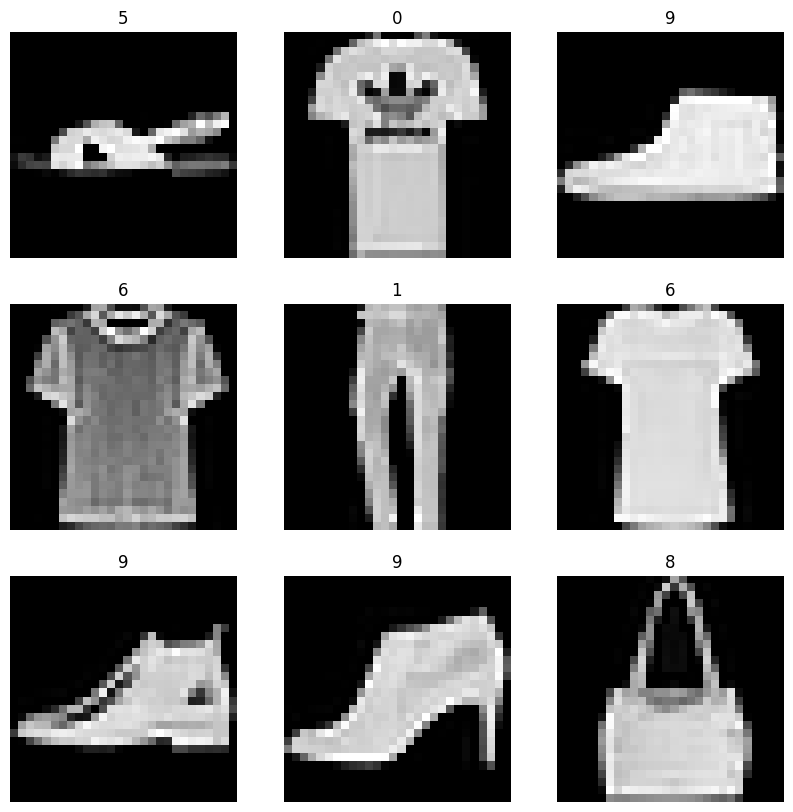

In [4]:
## now we take a look at the data set
sample_img_idx = np.random.randint(0, X_train.shape[0]+1, 9)
plt.figure(figsize=(10,10))
for i, j in enumerate(sample_img_idx):
    image, label = X_train[j], Y_train[j]
    ax=plt.subplot(3,3,i+1)
    plt.imshow(image, cmap = plt.get_cmap('gray'))
    plt.title(label)
    plt.axis('off')

from above, we can see the X_train are images, with dimensions 28*28, and there are 60000 of the training samples.
in the picture showed above, there are corresponding numbers labeled above the picture, which are the true lables of those picture.
according to the dataset discription:
*0 T-shirt/top
*1 Trouser
*2 Pullover
*3 Dress
*4 Coat
*5 Sandal
*6 Shirt
*7 Sneaker
*8 Bag
*9 Ankle boot

In [5]:
## for image datasets, the most common way to process them is verterising them as matrices
## each emach is a 28*28 matrix in this dataset, and there are 60,000 of them
## Thus, we need to reshape them as 60,000 * (28*28) format as the input features

X_train = X_train.reshape(60000,28*28)
X_test = X_test.reshape(10000,28*28)

## for multi-class classification problem, one-hot encoding is the easy way to represent the labels
## define the one-hot fuction
def one_hot(X):
  zeros = np.zeros(shape=(X.shape[0], 10))
  zeros[np.arange(X.size), X] = 1
  return zeros

Y_train = one_hot(Y_train)
Y_test = one_hot(Y_test)

## now we need to normalizing the images as it's important for for the neural netwarks. when we implement MLP,
## the training process involve backpropogating, which will accumulatively add the gradient
## we need to make sure the weights are proper throughout the trainig process

X_train = ((X_train-np.mean(X_train,axis=0))/np.std(X_train,axis=0))
X_test = ((X_test-np.mean(X_test,axis=0))/np.std(X_test,axis=0))

In [6]:
## now we need to further split the training set into trainning set and validation set
## we need validation set in the future when we apply the MLP, we need to find the most proper hyperparameters
## based on the accuracy generated by the validation set

## 3:1 = training : validation
## shuffle the dataset
p = np.random.permutation(X_train.shape[0])

## split
X_val, Y_val = X_train[p[:15000]], Y_train[p[:15000]]
X_train, Y_train = X_train[p[15000:]], Y_train[p[15000:]]

Building the MLP

Input (784,)  ← 28x28 image flattened

   ↓

Dense (128 units, ReLU)

   ↓

Dropout (20%)

   ↓

Dense (64 units, ReLU)

   ↓

Dropout (20%)

   ↓

Dense (10 units, Softmax)

In [17]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))  # 10 classes

In [18]:
# compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [19]:
# train the Model
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, Y_val)
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6992 - loss: 0.8806 - val_accuracy: 0.8567 - val_loss: 0.3989
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8364 - loss: 0.4555 - val_accuracy: 0.8692 - val_loss: 0.3635
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8558 - loss: 0.3836 - val_accuracy: 0.8744 - val_loss: 0.3458
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8631 - loss: 0.3731 - val_accuracy: 0.8801 - val_loss: 0.3297
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8744 - loss: 0.3436 - val_accuracy: 0.8825 - val_loss: 0.3255
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8785 - loss: 0.3287 - val_accuracy: 0.8825 - val_loss: 0.3262
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8812 - loss: 0.3216 - val_accuracy: 0.8858 - val_loss: 0.3132
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8857 - loss: 0.3077 - val_accuracy: 0

In [20]:
# test the model
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8794 - loss: 0.3412
Test accuracy: 0.8757


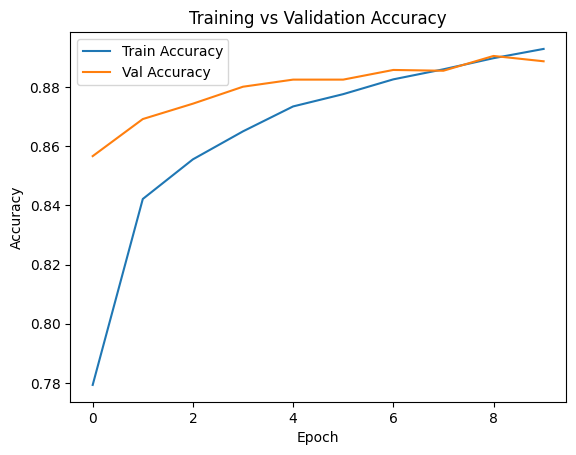

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

**Training accuracy** (blue) is steadily increasing across epochs.

**Validation accuracy** (orange) is also increasing and then flattening around epoch 5–6.

There is no major overfitting (training accuracy slightly surpasses validation accuracy but not dramatically).

Validation accuracy levels off around 88.5–89%, which is very solid for a basic MLP on Fashion MNIST.
Training continues to improve slowly — maybe consider early stopping if it plateaus.



# Build a CNN for Fashion-MINST

**Architecture**

Input: 28x28x1 image

   ↓

Conv2D (32 filters, 3x3 kernel, ReLU)

   ↓

MaxPooling2D (2x2)

   ↓

Conv2D (64 filters, 3x3 kernel, ReLU)

   ↓

MaxPooling2D (2x2)

   ↓

Flatten

   ↓

Dense (128 units, ReLU)

   ↓

Dropout (0.5)

   ↓

Dense (10 units, Softmax)


In [23]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion MNIST data
(X_train_full, Y_train_full), (X_test, Y_test) = fashion_mnist.load_data()

# Reshape to add channel dimension for CNN: (28, 28, 1)
X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Normalize to [0, 1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Split training data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.25, random_state=42
)

# Build CNN model
cnn_model = Sequential()
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(10, activation='softmax'))

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_cnn = cnn_model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, Y_val)
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.6463 - loss: 0.9880 - val_accuracy: 0.8365 - val_loss: 0.4319
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - accuracy: 0.8353 - loss: 0.4604 - val_accuracy: 0.8679 - val_loss: 0.3642
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - accuracy: 0.8635 - loss: 0.3870 - val_accuracy: 0.8811 - val_loss: 0.3206
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.8776 - loss: 0.3465 - val_accuracy: 0.8892 - val_loss: 0.2974
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 113ms/step - accuracy: 0.8841 - loss: 0.3257 - val_accuracy: 0.8921 - val_loss: 0.2870
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.8888 - loss: 0.3070 - val_accuracy: 0.8995 - val_loss: 0.2682
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.8925 - loss: 0.2907 - val_accuracy: 0.8978 - val_loss: 0.2729
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.8997 - loss: 0

In [24]:
# testing the model
test_loss, test_acc = cnn_model.evaluate(X_test, Y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9037 - loss: 0.2721
Test accuracy: 0.9042


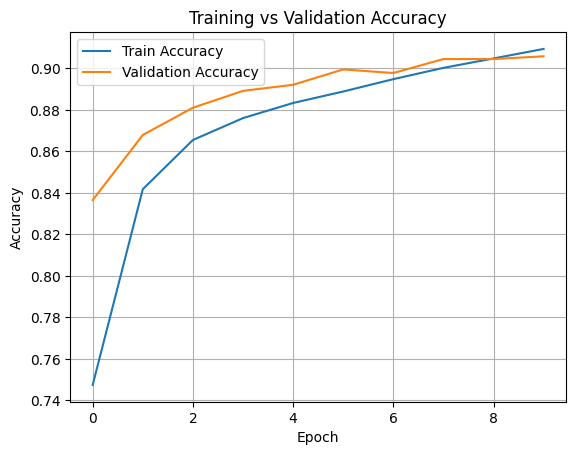

In [26]:
# Accuracy over epochs
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


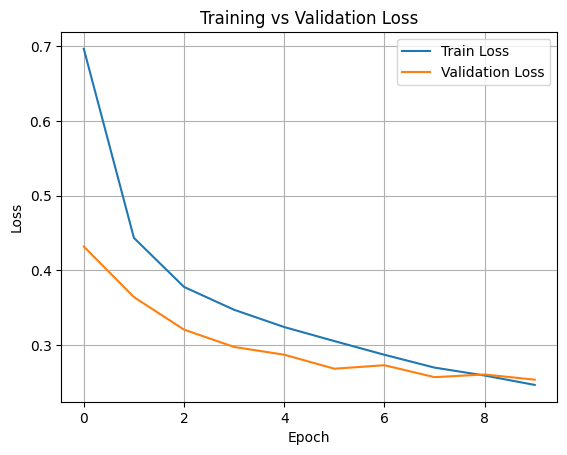

In [27]:
# Loss over epochs
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


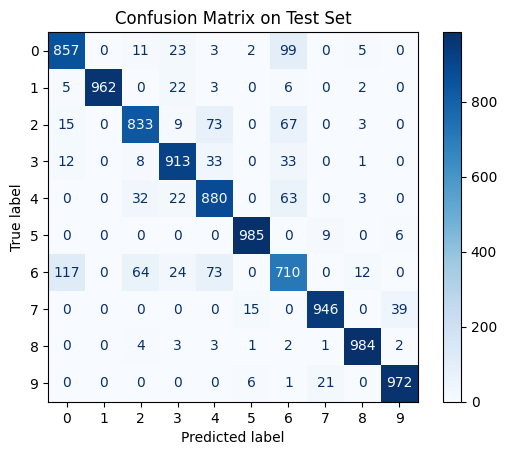

In [28]:
# Confusion Matrix - where the model makes mistakes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict classes on test set
Y_pred = cnn_model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)

# Plot confusion matrix
cm = confusion_matrix(Y_test, Y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()